# OCEAN LoRA-combination experiment — starter analysis

Downloads the per-config TRAIT + MMLU results from HF, aggregates each config to a
mean value with **ci95 error bars** (Wilson for the binary MMLU accuracy, BCa
bootstrap for the continuous trait scores — per the repo convention), and plots
the 32 configs against **Σscale** (total adapter magnitude) on the x-axis.

Starter scaffolding — extend with the regressions / groupings you actually want.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from huggingface_hub.errors import EntryNotFoundError

from scripts_dev.combinations_experiment.config_design import TRAITS, generate_design
from scripts_dev.combinations_experiment.run_experiment import HF_PREFIX, HF_REPO_ID
from src_dev.utils.hf_hub import download_path_to_dir
# CLAUDE.md sanctions using these interval helpers directly; reuse the per-sample
# parser rather than reimplementing its four scoring conventions.
from src_dev.evals.personality.analyze_results import (
    _extract_raw_sample_scores,
    _interval_ci_from_bootstrap,
    _interval_ci_from_wilson,
)

load_dotenv()

CACHE_ROOT = Path("scratch/combinations_experiment_analysis/cache")
CONFIDENCE = 95
BOOT_RESAMPLES = 1000
BOOT_SEED = 42
DOWNLOAD = True  # set False to reuse a previously downloaded cache

In [2]:
def _log_json(config_dir: Path, eval_name: str) -> Path | None:
    # Latest log (timestamped name) — defensive against any stale earlier log.
    logs = sorted((config_dir / eval_name / "native" / "inspect_logs").glob("*.json"))
    return logs[-1] if logs else None


def _mmlu_mean_ci(log_path: Path) -> tuple[float, float, float] | None:
    """MMLU accuracy: mean + Wilson ci95 over the binary 0/1 per-sample scores."""
    raw = _extract_raw_sample_scores(log_path, "mmlu")
    if not raw or "accuracy" not in raw:
        return None
    vals = np.asarray(raw["accuracy"], dtype=float)
    lo, hi = _interval_ci_from_wilson(vals, CONFIDENCE)
    return float(vals.mean()), lo, hi


def _trait_means_ci(log_path: Path) -> dict[str, tuple[float, float, float]]:
    """Per-trait score: mean + bootstrap ci95 over the continuous per-sample scores."""
    raw = _extract_raw_sample_scores(log_path, "trait_logprobs") or {}
    out: dict[str, tuple[float, float, float]] = {}
    for key, scores in raw.items():
        if key.startswith("_"):
            continue  # skip helper keys (_cm_*, _nc_*, _choice_mass)
        letter = key[0].upper()  # Openness->O, Conscientiousness->C, ...
        vals = np.asarray(scores, dtype=float)
        lo, hi = _interval_ci_from_bootstrap(vals, CONFIDENCE, BOOT_RESAMPLES, BOOT_SEED)
        out[letter] = (float(vals.mean()), lo, hi)
    return out

In [3]:
design = generate_design()
rows = []
missing = []

for record in design.configs:
    config_dir = CACHE_ROOT / record.slug
    if DOWNLOAD:
        try:
            download_path_to_dir(
                repo_id=HF_REPO_ID,
                path_in_repo=f"{HF_PREFIX}/{record.slug}",
                target_dir=config_dir,
                allow_patterns=["**/*.json"],
            )
        except EntryNotFoundError:
            missing.append(record.slug)  # not uploaded yet (run still in progress)
            continue
    if not config_dir.exists():
        missing.append(record.slug)
        continue

    row = {"slug": record.slug, "sumscale": record.sumscale_actual}
    for t in record.traits:
        row[f"dir_{t.letter}"] = t.direction

    mmlu_log = _log_json(config_dir, "mmlu")
    if mmlu_log is not None and (res := _mmlu_mean_ci(mmlu_log)) is not None:
        row["mmlu_mean"], row["mmlu_lo"], row["mmlu_hi"] = res

    trait_log = _log_json(config_dir, "trait_logprobs")
    if trait_log is not None:
        for letter, (mean, lo, hi) in _trait_means_ci(trait_log).items():
            row[f"trait_{letter}_mean"] = mean
            row[f"trait_{letter}_lo"] = lo
            row[f"trait_{letter}_hi"] = hi

    rows.append(row)

df = pd.DataFrame(rows)
if not df.empty:
    df = df.sort_values("sumscale").reset_index(drop=True)
n_mmlu = int(df["mmlu_mean"].notna().sum()) if "mmlu_mean" in df.columns else 0
print(f"{len(df)} configs loaded; {len(missing)} not on HF yet; {n_mmlu} with MMLU results")
df

run_info.json: 0.00B [00:00, ?B/s]

combinations_experiments/llama-3.1-8b-it(…):   0%|          | 0.00/58.1M [00:00<?, ?B/s]

run_info.json: 0.00B [00:00, ?B/s]

(…)_mmlu-0-shot_MHPXTX3aiPKZfg5QoHBFWr.json: 0.00B [00:00, ?B/s]

run_info.json: 0.00B [00:00, ?B/s]

...

combinations_experiments/llama-3.1-8b-it(…):   0%|          | 0.00/58.6M [00:00<?, ?B/s]

run_info.json: 0.00B [00:00, ?B/s]

(…)_mmlu-0-shot_LcbcTK7iGSf6muwJTYsSLD.json: 0.00B [00:00, ?B/s]

32 configs loaded; 0 not on HF yet; 32 with MMLU results


,slug,sumscale,dir_O,dir_C,dir_E,dir_A,dir_N,mmlu_mean,mmlu_lo,mmlu_hi,...,trait_N_hi,trait_E_mean,trait_E_lo,trait_E_hi,trait_O_mean,trait_O_lo,trait_O_hi,trait_A_mean,trait_A_lo,trait_A_hi
0,OP0p18_CP0p11_EM0p11_AM0p10_NP0p07,0.57,P,P,M,M,P,0.606667,5.503753e-01,0.660261,...,0.242275,0.517098,0.471901,0.563338,0.802610,0.766702,0.831743,0.867720,0.835656,0.893921
1,OM0p13_CM0p09_EM0p06_AP0p07_NP0p31,0.66,M,M,M,P,P,0.630000,5.740446e-01,0.682668,...,0.271434,0.526067,0.482438,0.572978,0.751630,0.715297,0.783021,0.861895,0.830464,0.888592
2,OM0p06_CM0p13_EM0p17_AM0p37_NM0p08,0.81,M,M,M,M,M,0.606667,5.503753e-01,0.660261,...,0.276911,0.473660,0.430053,0.519512,0.727295,0.690498,0.760941,0.817998,0.781640,0.846086
3,OP0p13_CP0p17_EP0p15_AP0p09_NM0p36,0.90,P,P,P,P,M,0.593333,5.369084e-01,0.647398,...,0.167570,0.623780,0.579640,0.666894,0.859350,0.825210,0.884920,0.888967,0.858593,0.912685
4,OP0p19_CM0p09_EM0p06_AM0p44_NM0p17,0.95,P,M,M,M,M,0.590000,5.335482e-01,0.644176,...,0.236069,0.529164,0.489004,0.570731,0.817126,0.785861,0.843244,0.830630,0.795247,0.856608
5,OM0p27_CM0p18_EP0p43_AM0p21_NM0p07,1.16,M,M,P,M,M,0.610000,5.537486e-01,0.663470,...,0.225692,0.680462,0.642477,0.717738,0.847664,0.820225,0.869740,0.859904,0.829233,0.882338
6,OP0p51_CP0p17_EM0p15_AM0p30_NM0p10,1.23,P,P,M,M,M,0.543333,4.867738e-01,0.598797,...,0.196077,0.575772,0.537926,0.614636,0.888421,0.865581,0.907354,0.859643,0.830126,0.882016
7,OM0p29_CP0p20_EP0p25_AM0p06_NM0p56,1.36,M,P,P,M,M,0.610000,5.537486e-01,0.663470,...,0.163346,0.603840,0.559083,0.646808,0.805951,0.771505,0.835059,0.856936,0.820874,0.883919
8,OM0p64_CP0p16_EM0p29_AM0p16_NM0p14,1.39,M,P,M,M,M,0.576667,5.201333e-01,0.631261,...,0.275806,0.392491,0.356144,0.435387,0.575924,0.534891,0.617770,0.771182,0.734099,0.802999
9,OM0p14_CM0p05_EM0p25_AM0p12_NP0p98,1.54,M,M,M,M,P,0.543333,4.867738e-01,0.598797,...,0.444875,0.513603,0.482588,0.549263,0.733670,0.703978,0.757089,0.766662,0.736993,0.789850


In [4]:

# trait	full ‖ΔW‖	rank-1 (committed)	ratio
# openness+	6.078	2.579	2.36×
# openness−	6.322	2.887	2.19×
# conscientiousness+	6.332	2.687	2.36×
# conscientiousness−	6.383	2.527	2.53×
# extraversion+	6.451	2.575	2.51×
# extraversion−	6.383	2.841	2.25×
# agreeableness+	6.463	2.682	2.41×
# agreeableness−	6.185	2.597	2.38×
# neuroticism+	6.529	2.548	2.56×
# neuroticism−	6.336	2.680	2.36×



In [50]:
import json
from pathlib import Path

import scripts_dev.combinations_experiment.config_design as _cd

# Full-rank ||Delta W|| of each OCEAN LoRA (computed in scripts_dev/flatten_loras).
_repo = Path(_cd.__file__).resolve().parents[2]
full_norms = pd.Series(
    json.loads(
        (_repo / "scripts_dev/flatten_loras/data/persona_vectors/full_norms.json").read_text()
    ),
    name="full_rank_norm",
)
print("Full-rank ||Delta W|| per OCEAN LoRA:")
print(full_norms.to_string())
full_norms


Full-rank ||Delta W|| per OCEAN LoRA:
o_plus     6.0779
o_minus    6.3217
c_plus     6.3320
c_minus    6.3833
e_plus     6.4515
e_minus    6.3827
a_plus     6.4631
a_minus    6.1846
n_plus     6.5286
n_minus    6.3364


o_plus     6.0779
o_minus    6.3217
c_plus     6.3320
c_minus    6.3833
e_plus     6.4515
e_minus    6.3827
a_plus     6.4631
a_minus    6.1846
n_plus     6.5286
n_minus    6.3364
Name: full_rank_norm, dtype: float64

In [5]:
import plotly.graph_objects as go

# MMLU vs the largest single adapter scale in each config. Hover = combo slug.
_maxscale = {rec.slug: max(t.scale for t in rec.traits) for rec in generate_design().configs}
df["maxscale"] = df["slug"].map(_maxscale)

if "mmlu_mean" not in df.columns or df["mmlu_mean"].notna().sum() == 0:
    print("No MMLU results yet — skipping plot.")
else:
    d = df.dropna(subset=["mmlu_mean"])
    fig = go.Figure(go.Scatter(
        x=d["maxscale"], y=d["mmlu_mean"], mode="markers",
        marker=dict(size=8, color="seagreen"),
        error_y=dict(
            type="data", symmetric=False,
            array=np.clip(d["mmlu_hi"] - d["mmlu_mean"], 0, None),
            arrayminus=np.clip(d["mmlu_mean"] - d["mmlu_lo"], 0, None),
            color="lightgray", thickness=1,
        ),
        text=d["slug"],
        hovertemplate="%{text}<br>max scale=%{x:.2f}<br>MMLU=%{y:.3f}<extra></extra>",
    ))
    fig.update_layout(
        xaxis_title="max single adapter scale", yaxis_title="MMLU accuracy",
        title="MMLU vs largest single adapter scale (Wilson ci95)",
        height=460, width=720,
    )
    fig.show()

In [6]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# MMLU (y, shared) vs each trait's own signed adapter scale (x).
# Hover shows the combo slug + Σscale; points coloured by Σscale (shared colorbar).
_scale_map = {
    rec.slug: {t.letter: t.signed_scale for t in rec.traits}
    for rec in generate_design().configs
}
for _L in TRAITS:
    df[f"scale_{_L}"] = df["slug"].map(lambda s, _L=_L: _scale_map[s][_L])

if "mmlu_mean" not in df.columns or df["mmlu_mean"].notna().sum() == 0:
    print("No MMLU results yet — skipping plot.")
else:
    d = df.dropna(subset=["mmlu_mean"])
    fig = make_subplots(rows=1, cols=len(TRAITS), shared_yaxes=True, subplot_titles=list(TRAITS))
    for i, letter in enumerate(TRAITS, start=1):
        fig.add_trace(go.Scatter(
            x=d[f"scale_{letter}"], y=d["mmlu_mean"], mode="markers",
            marker=dict(size=6, color=d["sumscale"], coloraxis="coloraxis"),
            error_y=dict(
                type="data", symmetric=False,
                array=np.clip(d["mmlu_hi"] - d["mmlu_mean"], 0, None),
                arrayminus=np.clip(d["mmlu_mean"] - d["mmlu_lo"], 0, None),
                color="lightgray", thickness=1,
            ),
            text=d["slug"], customdata=d["sumscale"],
            hovertemplate="%{text}<br>" + letter
            + " scale=%{x:.2f}<br>MMLU=%{y:.3f}<br>Σscale=%{customdata:.2f}<extra></extra>",
            showlegend=False,
        ), row=1, col=i)
        fig.add_vline(x=0.0, line_dash="dash", line_color="gray", line_width=1, row=1, col=i)
        fig.update_xaxes(title_text=f"{letter} scale", row=1, col=i)
    fig.update_yaxes(title_text="MMLU accuracy", row=1, col=1)
    fig.update_layout(
        title="MMLU vs each trait's signed adapter scale (+ amplifier, − suppressor)",
        coloraxis=dict(colorscale="Viridis", colorbar=dict(title="Σscale")),
        height=360, width=950,
    )
    fig.show()

In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Same as above, but points coloured by max single adapter scale (shared colorbar).
_scale_map = {
    rec.slug: {t.letter: t.signed_scale for t in rec.traits}
    for rec in generate_design().configs
}
for _L in TRAITS:
    df[f"scale_{_L}"] = df["slug"].map(lambda s, _L=_L: _scale_map[s][_L])
df["maxscale"] = df["slug"].map(
    {rec.slug: max(t.scale for t in rec.traits) for rec in generate_design().configs}
)

if "mmlu_mean" not in df.columns or df["mmlu_mean"].notna().sum() == 0:
    print("No MMLU results yet — skipping plot.")
else:
    d = df.dropna(subset=["mmlu_mean"])
    fig = make_subplots(rows=1, cols=len(TRAITS), shared_yaxes=True, subplot_titles=list(TRAITS))
    for i, letter in enumerate(TRAITS, start=1):
        fig.add_trace(go.Scatter(
            x=d[f"scale_{letter}"], y=d["mmlu_mean"], mode="markers",
            marker=dict(size=6, color=d["maxscale"], coloraxis="coloraxis"),
            error_y=dict(
                type="data", symmetric=False,
                array=np.clip(d["mmlu_hi"] - d["mmlu_mean"], 0, None),
                arrayminus=np.clip(d["mmlu_mean"] - d["mmlu_lo"], 0, None),
                color="lightgray", thickness=1,
            ),
            text=d["slug"], customdata=d["maxscale"],
            hovertemplate="%{text}<br>" + letter
            + " scale=%{x:.2f}<br>MMLU=%{y:.3f}<br>max scale=%{customdata:.2f}<extra></extra>",
            showlegend=False,
        ), row=1, col=i)
        fig.add_vline(x=0.0, line_dash="dash", line_color="gray", line_width=1, row=1, col=i)
        fig.update_xaxes(title_text=f"{letter} scale", row=1, col=i)
    fig.update_yaxes(title_text="MMLU accuracy", row=1, col=1)
    fig.update_layout(
        title="MMLU vs each trait's signed adapter scale — coloured by max single scale",
        coloraxis=dict(colorscale="Viridis", colorbar=dict(title="max scale")),
        height=360, width=950,
    )
    fig.show()

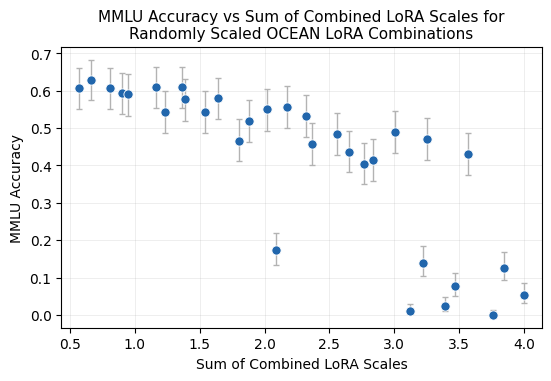

In [53]:
import matplotlib.pyplot as plt

# MMLU accuracy vs total adapter magnitude (Sigma scale), Wilson ci95 error bars.
# Paper-friendly matplotlib version.
if "mmlu_mean" not in df.columns or df["mmlu_mean"].notna().sum() == 0:
    print("No MMLU results yet - skipping plot.")
else:
    d = df.dropna(subset=["mmlu_mean"]).sort_values("sumscale")
    x = d["sumscale"].to_numpy()
    y = d["mmlu_mean"].to_numpy()
    yerr = np.vstack([
        np.clip(y - d["mmlu_lo"].to_numpy(), 0, None),
        np.clip(d["mmlu_hi"].to_numpy() - y, 0, None),
    ])

    fig, ax = plt.subplots(figsize=(5.4, 3.7), layout="constrained")
    ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="0.7", elinewidth=1.0,
                capsize=2.5, capthick=1.0, zorder=1)
    ax.scatter(x, y, s=44, color="#2166ac", edgecolors="white", linewidths=0.6,
               zorder=2)
    ax.set_xlabel("Sum of Combined LoRA Scales")
    ax.set_ylabel("MMLU Accuracy")
    ax.set_title("MMLU Accuracy vs Sum of Combined LoRA Scales for\n"
                 "Randomly Scaled OCEAN LoRA Combinations", fontsize=11)
    ax.grid(True, alpha=0.25, lw=0.6)
    ax.margins(x=0.04)
    plt.show()


In [9]:
import json

import plotly.graph_objects as go

import scripts_dev.combinations_experiment.config_design as _cd

REPO_ROOT = Path(_cd.__file__).resolve().parents[2]

# x = Σ (scaleᵢ × full-rank ‖ΔWᵢ‖): magnitude-weighted total adapter intervention.
FULL_NORMS = json.loads(
    (REPO_ROOT / "scripts_dev/flatten_loras/data/persona_vectors/full_norms.json").read_text()
)
norm_weighted = {
    rec.slug: sum(FULL_NORMS[slug] * scale for slug, scale in rec.adapters)
    for rec in generate_design().configs
}
df["norm_weighted"] = df["slug"].map(norm_weighted)

if "mmlu_mean" not in df.columns or df["mmlu_mean"].notna().sum() == 0:
    print("No MMLU results yet — skipping plot.")
else:
    d = df.dropna(subset=["mmlu_mean"])
    fig = go.Figure(go.Scatter(
        x=d["norm_weighted"], y=d["mmlu_mean"], mode="markers",
        marker=dict(size=8, color="mediumpurple"),
        error_y=dict(
            type="data", symmetric=False,
            array=np.clip(d["mmlu_hi"] - d["mmlu_mean"], 0, None),
            arrayminus=np.clip(d["mmlu_mean"] - d["mmlu_lo"], 0, None),
            color="lightgray", thickness=1,
        ),
        text=d["slug"],
        hovertemplate="%{text}<br>Σ(scale·norm)=%{x:.2f}<br>MMLU=%{y:.3f}<extra></extra>",
    ))
    fig.update_layout(
        xaxis_title="Σ (scale × full-rank ‖ΔW‖)  — magnitude-weighted total",
        yaxis_title="MMLU accuracy",
        title="MMLU vs magnitude-weighted adapter total (Wilson ci95)",
        height=460, width=720,
    )
    fig.show()

In [10]:
import json

import plotly.graph_objects as go

import scripts_dev.combinations_experiment.config_design as _cd

REPO_ROOT = Path(_cd.__file__).resolve().parents[2]

# x = full-rank ‖combined ΔW‖ (Σ scaleᵢ·ΔWᵢ): captures interference between the 5
# adapters (cancellation/reinforcement), unlike the sum-of-magnitudes axis above.
COMBINED_NORMS = json.loads(
    (REPO_ROOT / "scripts_dev/combinations_experiment/combined_full_norms.json").read_text()
)
df["combined_norm"] = df["slug"].map(COMBINED_NORMS)

if "mmlu_mean" not in df.columns or df["mmlu_mean"].notna().sum() == 0:
    print("No MMLU results yet — skipping plot.")
else:
    d = df.dropna(subset=["mmlu_mean", "combined_norm"])
    fig = go.Figure(go.Scatter(
        x=d["combined_norm"], y=d["mmlu_mean"], mode="markers",
        marker=dict(size=8, color="firebrick"),
        error_y=dict(
            type="data", symmetric=False,
            array=np.clip(d["mmlu_hi"] - d["mmlu_mean"], 0, None),
            arrayminus=np.clip(d["mmlu_mean"] - d["mmlu_lo"], 0, None),
            color="lightgray", thickness=1,
        ),
        text=d["slug"],
        hovertemplate="%{text}<br>‖combined ΔW‖=%{x:.2f}<br>MMLU=%{y:.3f}<extra></extra>",
    ))
    fig.update_layout(
        xaxis_title="full-rank ‖combined ΔW‖  (Σ scaleᵢ·ΔWᵢ)",
        yaxis_title="MMLU accuracy",
        title="MMLU vs combined-adapter norm (Wilson ci95)",
        height=460, width=720,
    )
    fig.show()

In [11]:
df

,slug,sumscale,dir_O,dir_C,dir_E,dir_A,dir_N,mmlu_mean,mmlu_lo,mmlu_hi,...,trait_A_lo,trait_A_hi,maxscale,scale_O,scale_C,scale_E,scale_A,scale_N,norm_weighted,combined_norm
0,OP0p18_CP0p11_EM0p11_AM0p10_NP0p07,0.57,P,P,M,M,P,0.606667,5.503753e-01,0.660261,...,0.835656,0.893921,0.18,0.18,0.11,-0.11,-0.10,0.07,3.568101,1.755842
1,OM0p13_CM0p09_EM0p06_AP0p07_NP0p31,0.66,M,M,M,P,P,0.630000,5.740446e-01,0.682668,...,0.830464,0.888592,0.31,-0.13,-0.09,-0.06,0.07,0.31,4.255563,2.410757
2,OM0p06_CM0p13_EM0p17_AM0p37_NM0p08,0.81,M,M,M,M,M,0.606667,5.503753e-01,0.660261,...,0.781640,0.846086,0.37,-0.06,-0.13,-0.17,-0.37,-0.08,5.089404,2.868862
3,OP0p13_CP0p17_EP0p15_AP0p09_NM0p36,0.90,P,P,P,P,M,0.593333,5.369084e-01,0.647398,...,0.858593,0.912685,0.36,0.13,0.17,0.15,0.09,-0.36,5.697075,3.047690
4,OP0p19_CM0p09_EM0p06_AM0p44_NM0p17,0.95,P,M,M,M,M,0.590000,5.335482e-01,0.644176,...,0.795247,0.856608,0.44,0.19,-0.09,-0.06,-0.44,-0.17,5.910672,3.331684
5,OM0p27_CM0p18_EP0p43_AM0p21_NM0p07,1.16,M,M,P,M,M,0.610000,5.537486e-01,0.663470,...,0.829233,0.882338,0.43,-0.27,-0.18,0.43,-0.21,-0.07,7.372312,3.855778
6,OP0p51_CP0p17_EM0p15_AM0p30_NM0p10,1.23,P,P,M,M,M,0.543333,4.867738e-01,0.598797,...,0.830126,0.882016,0.51,0.51,0.17,-0.15,-0.30,-0.10,7.622594,4.101252
7,OM0p29_CP0p20_EP0p25_AM0p06_NM0p56,1.36,M,P,P,M,M,0.610000,5.537486e-01,0.663470,...,0.820874,0.883919,0.56,-0.29,0.20,0.25,-0.06,-0.56,8.632028,4.720084
8,OM0p64_CP0p16_EM0p29_AM0p16_NM0p14,1.39,M,P,M,M,M,0.576667,5.201333e-01,0.631261,...,0.734099,0.802999,0.64,-0.64,0.16,-0.29,-0.16,-0.14,8.786623,5.076352
9,OM0p14_CM0p05_EM0p25_AM0p12_NP0p98,1.54,M,M,M,M,P,0.543333,4.867738e-01,0.598797,...,0.736993,0.789850,0.98,-0.14,-0.05,-0.25,-0.12,0.98,9.940058,6.819047


In [12]:
list(df[(df["mmlu_mean"] > 0.3) & (df["combined_norm"] > 8.5)]["slug"])

['OP0p60_CM0p20_EM0p54_AM0p14_NP1p17',
 'OP0p34_CP0p37_EP1p17_AM0p49_NP0p40',
 'OM0p30_CP0p51_EM1p71_AP0p14_NM0p18',
 'OM1p35_CM0p39_EP0p87_AP0p24_NP0p16',
 'OM1p92_CP0p28_EP0p53_AP0p13_NM0p39',
 'OM0p99_CP0p27_EP1p11_AP1p09_NP0p11']

## Interactive 3D scale-space

Each config plotted in OCEAN **scale-space**. The dropdown picks which 3 traits go on
the x/y/z axes (signed scale: + amplifier, − suppressor). Points are the 32 configs,
coloured by MMLU accuracy — eyeball which scale combinations tank capability (dark)
vs stay intact (bright). Single plotly figure with a native dropdown, same format as
the `flatten_loras` exploration notebooks (needs a live kernel to render).

In [13]:
import itertools

import plotly.graph_objects as go

# Per-trait signed scale (+ amplifier, − suppressor) for each config.
_scale_map = {
    rec.slug: {t.letter: t.signed_scale for t in rec.traits}
    for rec in generate_design().configs
}
for _L in TRAITS:
    df[f"scale_{_L}"] = df["slug"].map(lambda s, _L=_L: _scale_map[s][_L])

_d = df.dropna(subset=["mmlu_mean"]).copy() if "mmlu_mean" in df.columns else df.iloc[:0]

if _d.empty:
    print("No MMLU results yet.")
else:
    # One trace per (x, y, z) trait triple; a plotly dropdown toggles which is shown.
    # Single go.Figure + one fig.show() — same pattern as the flatten_loras notebook
    # (no ipywidgets, so nothing stacks).
    triples = list(itertools.combinations(TRAITS, 3))  # 10 combos, axes in OCEAN order
    cmin, cmax = _d["mmlu_mean"].min(), _d["mmlu_mean"].max()
    sizes = _d["sumscale"] * 4.0  # marker size ∝ total adapter magnitude (Σscale)

    fig = go.Figure()
    for k, (xa, ya, za) in enumerate(triples):
        fig.add_trace(go.Scatter3d(
            x=_d[f"scale_{xa}"], y=_d[f"scale_{ya}"], z=_d[f"scale_{za}"],
            mode="markers", text=_d["slug"],
            customdata=_d["sumscale"],
            marker=dict(
                size=sizes, color=_d["mmlu_mean"], colorscale="Viridis",
                colorbar=dict(title="MMLU acc"), showscale=True, cmin=cmin, cmax=cmax,
            ),
            hovertemplate="%{text}<br>MMLU=%{marker.color:.3f}<br>Σscale=%{customdata:.2f}<extra></extra>",
            visible=(k == 0),
            name=f"{xa}{ya}{za}",
        ))

    buttons = [
        dict(
            method="update",
            label=f"{xa}, {ya}, {za}",
            args=[
                {"visible": [j == k for j in range(len(triples))]},
                {
                    "scene.xaxis.title.text": f"signed scale {xa}",
                    "scene.yaxis.title.text": f"signed scale {ya}",
                    "scene.zaxis.title.text": f"signed scale {za}",
                },
            ],
        )
        for k, (xa, ya, za) in enumerate(triples)
    ]

    x0, y0, z0 = triples[0]
    fig.update_layout(
        updatemenus=[dict(buttons=buttons, x=0.0, y=1.0, xanchor="left", yanchor="top")],
        scene=dict(
            xaxis_title=f"signed scale {x0}",
            yaxis_title=f"signed scale {y0}",
            zaxis_title=f"signed scale {z0}",
        ),
        title="OCEAN scale-space — points = configs, size ∝ Σscale, colour = MMLU accuracy",
        height=700, margin=dict(l=0, r=0, t=40, b=0), showlegend=False,
    )
    fig.show()

## Per-trait dose–response

For each OCEAN trait: measured trait score (TRAIT eval, y) vs that trait's **own**
adapter scale in the combo (signed: + amplifier, − suppressor, x), bootstrap ci95 on y.
Shows whether turning a trait's adapter up/down actually moves the measured trait —
with the other 4 adapters also active (so vertical scatter reflects cross-trait
interference). Hover a point to see which combo it is.

In [14]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Per-trait dose–response: measured trait score (y) vs that trait's own signed
# adapter scale (x). Static plotly subplots; hover shows the combo slug.
_scale_map = {
    rec.slug: {t.letter: t.signed_scale for t in rec.traits}
    for rec in generate_design().configs
}
for _L in TRAITS:
    df[f"scale_{_L}"] = df["slug"].map(lambda s, _L=_L: _scale_map[s][_L])

if f"trait_{TRAITS[0]}_mean" not in df.columns or df[f"trait_{TRAITS[0]}_mean"].notna().sum() == 0:
    print("No TRAIT results yet — skipping plot.")
else:
    fig = make_subplots(rows=1, cols=len(TRAITS), shared_yaxes=True, subplot_titles=list(TRAITS))
    for i, letter in enumerate(TRAITS, start=1):
        mean_col = f"trait_{letter}_mean"
        d = df.dropna(subset=[mean_col])
        fig.add_trace(go.Scatter(
            x=d[f"scale_{letter}"], y=d[mean_col], mode="markers",
            marker=dict(size=6, color="royalblue"),
            error_y=dict(
                type="data", symmetric=False,
                array=np.clip(d[f"trait_{letter}_hi"] - d[mean_col], 0, None),
                arrayminus=np.clip(d[mean_col] - d[f"trait_{letter}_lo"], 0, None),
                color="lightgray", thickness=1,
            ),
            text=d["slug"],
            hovertemplate="%{text}<br>" + letter + " scale=%{x:.2f}<br>"
            + letter + " score=%{y:.3f}<extra></extra>",
            showlegend=False,
        ), row=1, col=i)
        fig.add_vline(x=0.0, line_dash="dash", line_color="gray", line_width=1, row=1, col=i)
        fig.update_xaxes(title_text=f"{letter} scale", row=1, col=i)
    fig.update_yaxes(title_text="trait score", row=1, col=1)
    fig.update_layout(
        title="Per-trait dose–response: measured score vs that trait's own adapter scale",
        height=380, width=950,
    )
    fig.show()

In [21]:
# Sum of the OTHER four adapters' scales for each (config, trait) datapoint
# — i.e. the "background" magnitude from the rest of the mix, and the colour
# variable used in the per-trait dose-response plot below.
other_scales = pd.Series(
    {
        (rec.slug, t.letter): sum(u.scale for u in rec.traits if u.letter != t.letter)
        for rec in generate_design().configs
        for t in rec.traits
    },
    name="sum_other_scales",
)
other_scales.index.names = ["slug", "trait"]
other_scales.describe()


count    160.000000
mean       1.808000
std        0.878149
min        0.350000
25%        1.087500
50%        1.705000
75%        2.502500
max        3.740000
Name: sum_other_scales, dtype: float64

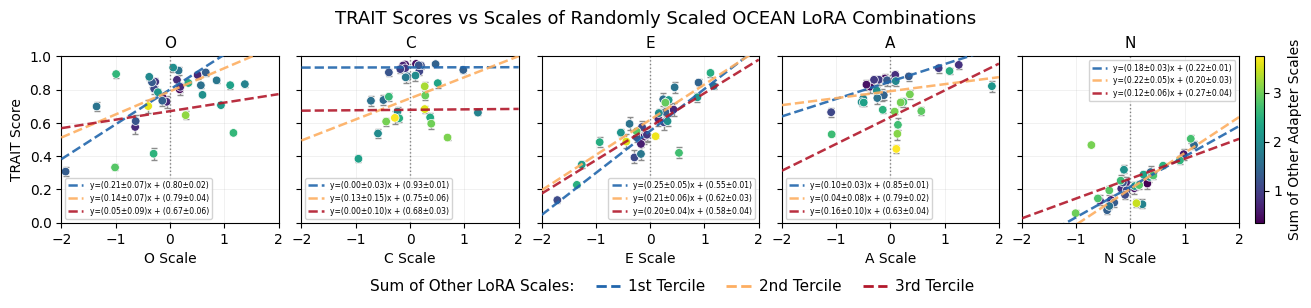

In [71]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# Per-trait dose-response (matplotlib, tight layout).
#   x = that trait's OWN signed adapter scale  (+ amplifier, - suppressor), fixed [-2, 2]
#   y = measured TRAIT score, with bootstrap ci95 error bars on each point
#   colour = sum of the OTHER four adapters' scales in that combo
#   one straight-line fit per tercile of THIS panel's sum-of-other-scales
#   (tercile colours/style like the MMLU plot; no CI band).
_recs = generate_design().configs
_signed = {rec.slug: {t.letter: t.signed_scale for t in rec.traits} for rec in _recs}
_other = {
    rec.slug: {
        t.letter: sum(u.scale for u in rec.traits if u.letter != t.letter)
        for t in rec.traits
    }
    for rec in _recs
}
for _L in TRAITS:
    df[f"scale_{_L}"] = df["slug"].map(lambda s, _L=_L: _signed[s][_L])
    df[f"other_{_L}"] = df["slug"].map(lambda s, _L=_L: _other[s][_L])

if f"trait_{TRAITS[0]}_mean" not in df.columns or df[f"trait_{TRAITS[0]}_mean"].notna().sum() == 0:
    print("No TRAIT results yet - skipping plot.")
else:
    _others = pd.concat([df[f"other_{L}"] for L in TRAITS])
    norm = Normalize(vmin=float(_others.min()), vmax=float(_others.max()))
    cmap = plt.get_cmap("viridis")
    QCOLORS = ["#2166ac", "#fdae61", "#b2182b"]  # low -> high other (terciles)
    rng = np.random.default_rng(BOOT_SEED)

    fig, axes = plt.subplots(1, len(TRAITS), sharey=True, figsize=(13, 3.0),
                             layout="constrained")
    for ax, letter in zip(axes, TRAITS):
        mean_col = f"trait_{letter}_mean"
        d = df.dropna(subset=[mean_col])
        x = d[f"scale_{letter}"].to_numpy()
        y = d[mean_col].to_numpy()
        o = d[f"other_{letter}"].to_numpy()
        # per-panel terciles of THIS trait's sum-of-other-scales
        QEDGES = np.quantile(o, [1/3, 2/3])
        yerr = np.vstack([
            np.clip(y - d[f"trait_{letter}_lo"].to_numpy(), 0, None),
            np.clip(d[f"trait_{letter}_hi"].to_numpy() - y, 0, None),
        ])
        # bootstrap ci95 error bars on each point (drawn behind the markers)
        ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="0.55",
                    elinewidth=1.0, capsize=2.5, capthick=1.0, zorder=1.8)
        ax.scatter(x, y, c=o, cmap=cmap, norm=norm,
                   s=38, edgecolors="white", linewidths=0.5, zorder=2)
        # straight-line (least-squares) fit per tercile of o (sum-of-other-scales);
        # full x-span, dashed, tercile-coloured, no CI band. Bootstrap SEs on the
        # slope/intercept are shown in the legend.
        qidx = np.digitize(o, QEDGES)  # 0..2
        for qi, qcol in enumerate(QCOLORS):
            mask = qidx == qi
            if mask.sum() >= 2:
                xm, ym = x[mask], y[mask]
                m, b = np.polyfit(xm, ym, 1)
                ms_bs = np.empty(BOOT_RESAMPLES)
                bs_bs = np.empty(BOOT_RESAMPLES)
                for k in range(BOOT_RESAMPLES):
                    idx = rng.integers(0, len(xm), len(xm))
                    ms_bs[k], bs_bs[k] = np.polyfit(xm[idx], ym[idx], 1)
                m_err, b_err = ms_bs.std(), bs_bs.std()
                ax.plot([-2.0, 2.0], [m * -2.0 + b, m * 2.0 + b], color=qcol,
                        lw=1.8, ls="--", alpha=0.9, zorder=4,
                        label=f"y=({m:.2f}±{m_err:.2f})x + ({b:.2f}±{b_err:.2f})")
        ax.legend(fontsize=5.5, loc="best", framealpha=0.85)
        ax.axvline(0.0, ls=":", color="gray", lw=1)
        ax.set_xlim(-2, 2)
        ax.set_ylim(0, 1)
        ax.set_xticks([-2, -1, 0, 1, 2])
        ax.set_title(letter, fontsize=11)
        ax.set_xlabel(f"{letter} Scale")
        ax.grid(True, alpha=0.25, lw=0.5)
    axes[0].set_ylabel("TRAIT Score")
    fig.suptitle("TRAIT Scores vs Scales of Randomly Scaled OCEAN LoRA Combinations", fontsize=13)
    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=axes,
                        fraction=0.02, pad=0.01)
    cbar.set_label("Sum of Other Adapter Scales")
    _terc = [Line2D([0], [0], color=QCOLORS[i], ls="--", lw=2) for i in range(3)]
    _desc = Line2D([0], [0], color="none")  # invisible handle -> inline label text
    fig.legend([_desc] + _terc,
               ["Sum of Other LoRA Scales:", "1st Tercile", "2nd Tercile", "3rd Tercile"],
               loc="outside lower center", ncol=4, frameon=False, fontsize=11,
               handlelength=1.6, columnspacing=1.4, handletextpad=0.5)
    plt.show()


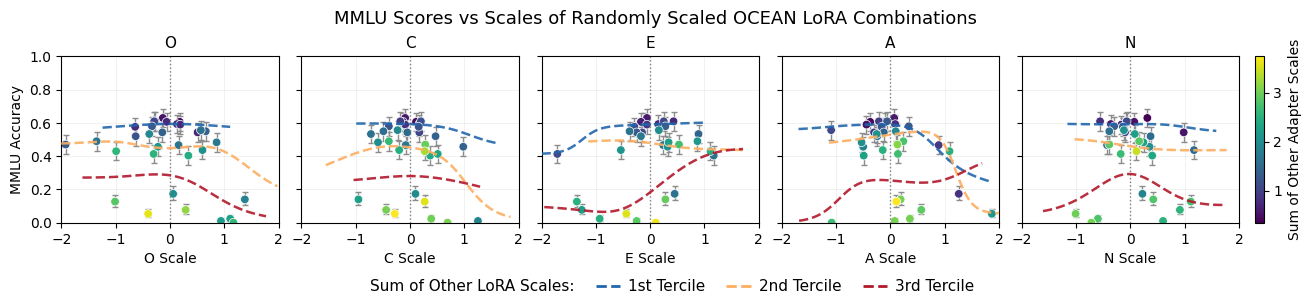

In [69]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# Same plot as the per-trait dose-response above, but MMLU accuracy on y.
#   x = that trait's OWN signed adapter scale  (+ amplifier, - suppressor), fixed [-2, 2]
#   y = MMLU accuracy (Wilson ci95), one value per config shown vs each trait's scale
#   colour = sum of the OTHER four adapters' scales in that combo
#   one rolling centre-of-mass curve per tercile of THIS panel's sum-of-other-scales.
_recs = generate_design().configs
_signed = {rec.slug: {t.letter: t.signed_scale for t in rec.traits} for rec in _recs}
_other = {
    rec.slug: {
        t.letter: sum(u.scale for u in rec.traits if u.letter != t.letter)
        for t in rec.traits
    }
    for rec in _recs
}
for _L in TRAITS:
    df[f"scale_{_L}"] = df["slug"].map(lambda s, _L=_L: _signed[s][_L])
    df[f"other_{_L}"] = df["slug"].map(lambda s, _L=_L: _other[s][_L])

if "mmlu_mean" not in df.columns or df["mmlu_mean"].notna().sum() == 0:
    print("No TRAIT results yet - skipping plot.")
else:
    _others = pd.concat([df[f"other_{L}"] for L in TRAITS])
    norm = Normalize(vmin=float(_others.min()), vmax=float(_others.max()))
    cmap = plt.get_cmap("viridis")
    COM_BW = 0.5  # bandwidth (scale units) for the rolling centre-of-mass curve
    QCOLORS = ["#2166ac", "#fdae61", "#b2182b"]  # low -> high other (terciles)

    fig, axes = plt.subplots(1, len(TRAITS), sharey=True, figsize=(13, 3.0),
                             layout="constrained")
    for ax, letter in zip(axes, TRAITS):
        d = df.dropna(subset=["mmlu_mean"])
        x = d[f"scale_{letter}"].to_numpy()
        y = d["mmlu_mean"].to_numpy()
        o = d[f"other_{letter}"].to_numpy()
        # per-panel terciles of THIS trait's sum-of-other-scales
        QEDGES = np.quantile(o, [1/3, 2/3])
        QLABELS = [
            f"T1 (≤{QEDGES[0]:.2f})",
            f"T2 ({QEDGES[0]:.2f}–{QEDGES[1]:.2f})",
            f"T3 (>{QEDGES[1]:.2f})",
        ]
        yerr = np.vstack([
            np.clip(y - d["mmlu_lo"].to_numpy(), 0, None),
            np.clip(d["mmlu_hi"].to_numpy() - y, 0, None),
        ])
        # Wilson ci95 error bars on each point (drawn behind the markers)
        ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor="0.55",
                    elinewidth=1.0, capsize=2.5, capthick=1.0, zorder=1.8)
        ax.scatter(x, y, c=o, cmap=cmap, norm=norm,
                   s=38, edgecolors="white", linewidths=0.5, zorder=2)
        # one rolling "centre of mass" curve per tercile of o (sum-of-other-scales):
        # Gaussian-kernel weighted mean of y over x within each third.
        qidx = np.digitize(o, QEDGES)  # 0..2
        for qi, qcol in enumerate(QCOLORS):
            mask = qidx == qi
            if mask.sum() >= 3:
                xm, ym = x[mask], y[mask]
                pad = 0.6  # extrapolate the COM curve past the data
                grid = np.linspace(max(-2.0, xm.min() - pad), min(2.0, xm.max() + pad), 100)
                w = np.exp(-0.5 * ((grid[:, None] - xm[None, :]) / COM_BW) ** 2)
                com = (w * ym[None, :]).sum(1) / w.sum(1)
                ax.plot(grid, com, color=qcol, lw=1.8, ls="--", alpha=0.9, zorder=4,
                        label=QLABELS[qi])
        ax.axvline(0.0, ls=":", color="gray", lw=1)
        ax.set_xlim(-2, 2)
        ax.set_ylim(0, 1)
        ax.set_xticks([-2, -1, 0, 1, 2])
        ax.set_title(letter, fontsize=11)
        ax.set_xlabel(f"{letter} Scale")
        ax.grid(True, alpha=0.25, lw=0.5)
    axes[0].set_ylabel("MMLU Accuracy")
    fig.suptitle("MMLU Scores vs Scales of Randomly Scaled OCEAN LoRA Combinations", fontsize=13)
    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=axes,
                        fraction=0.02, pad=0.01)
    cbar.set_label("Sum of Other Adapter Scales")
    _terc = [Line2D([0], [0], color=QCOLORS[i], ls="--", lw=2) for i in range(3)]
    _desc = Line2D([0], [0], color="none")  # invisible handle -> inline label text
    fig.legend([_desc] + _terc,
               ["Sum of Other LoRA Scales:", "1st Tercile", "2nd Tercile", "3rd Tercile"],
               loc="outside lower center", ncol=4, frameon=False, fontsize=11,
               handlelength=1.6, columnspacing=1.4, handletextpad=0.5)
    plt.show()


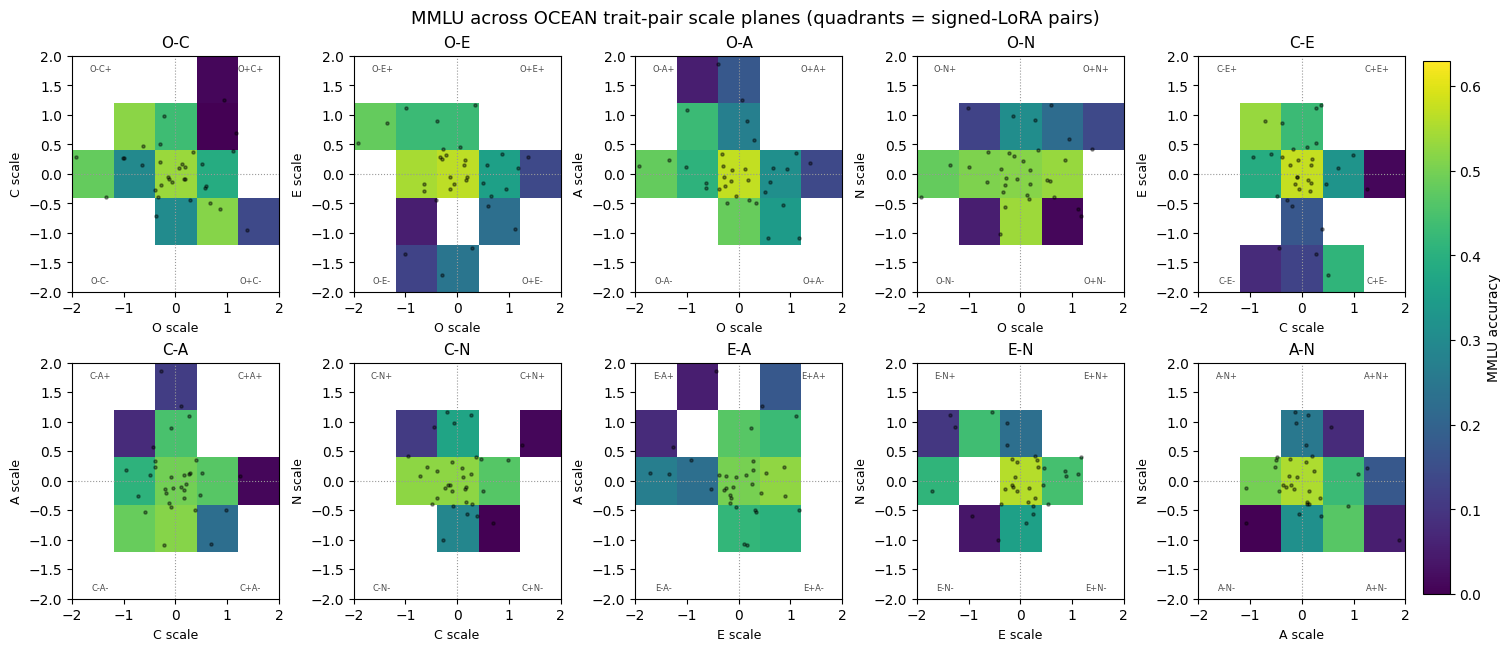

In [70]:
import itertools
import matplotlib.pyplot as plt

# MMLU over each OCEAN trait-pair's signed-scale plane. The SIGN of each axis is
# the direction, so the four quadrants ARE the four signed-LoRA pairs
# (top-right = a+ b+, bottom-left = a- b-, etc.) -- both the signed pairing AND
# the scale magnitude are preserved. Each cell = mean MMLU of the configs in that
# 2D scale bin; empty bins blank; black dots = the actual configs.
_signed = {rec.slug: {t.letter: t.signed_scale for t in rec.traits}
           for rec in generate_design().configs}
for _L in TRAITS:
    df[f"scale_{_L}"] = df["slug"].map(lambda s, _L=_L: _signed[s][_L])

if "mmlu_mean" not in df.columns or df["mmlu_mean"].notna().sum() == 0:
    print("No MMLU results yet - skipping plot.")
else:
    d = df.dropna(subset=["mmlu_mean"])
    mmlu = d["mmlu_mean"].to_numpy()
    pairs = list(itertools.combinations(TRAITS, 2))  # 10 trait pairs
    NBINS = 5
    edges = np.linspace(-2, 2, NBINS + 1)
    vmin, vmax = float(mmlu.min()), float(mmlu.max())
    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad("white")

    fig, axes = plt.subplots(2, 5, figsize=(15, 6.4), layout="constrained")
    im = None
    for ax, (a, b) in zip(axes.ravel(), pairs):
        xs = d[f"scale_{a}"].to_numpy()
        ys = d[f"scale_{b}"].to_numpy()
        sums, _, _ = np.histogram2d(xs, ys, bins=[edges, edges], weights=mmlu)
        cnts, _, _ = np.histogram2d(xs, ys, bins=[edges, edges])
        heat = np.divide(sums, cnts, out=np.full_like(sums, np.nan), where=cnts > 0)
        im = ax.imshow(heat.T, origin="lower", extent=[-2, 2, -2, 2], cmap=cmap,
                       vmin=vmin, vmax=vmax, aspect="auto", zorder=1)
        ax.scatter(xs, ys, c="k", s=5, alpha=0.4, zorder=2)
        ax.axhline(0, ls=":", color="0.6", lw=0.8)
        ax.axvline(0, ls=":", color="0.6", lw=0.8)
        # quadrant labels = the four signed-LoRA pairs
        qkw = dict(fontsize=6, color="0.3", ha="center", va="center", zorder=3)
        ax.text(1.45, 1.78, f"{a}+{b}+", **qkw)
        ax.text(-1.45, 1.78, f"{a}-{b}+", **qkw)
        ax.text(1.45, -1.82, f"{a}+{b}-", **qkw)
        ax.text(-1.45, -1.82, f"{a}-{b}-", **qkw)
        ax.set_xlabel(f"{a} scale", fontsize=9)
        ax.set_ylabel(f"{b} scale", fontsize=9)
        ax.set_title(f"{a}-{b}", fontsize=11)
    cbar = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01)
    cbar.set_label("MMLU accuracy")
    fig.suptitle("MMLU across OCEAN trait-pair scale planes (quadrants = signed-LoRA pairs)",
                 fontsize=13)
    plt.show()


## Same plots, but TRAIT *choice mass* instead of MMLU

"Choice mass" = how much probability the TRAIT logprob eval puts on the actual
answer-letter tokens (A/B/C/…) at the forced-answer position — i.e. a logit-level
measure of *format-following* (the analog of MMLU parse-rate). The cells below are
copies of every MMLU plot above, with choice mass (bootstrap ci95) on the axis
instead of MMLU accuracy.

In [48]:
import json

import scripts_dev.combinations_experiment.config_design as _cd

REPO_ROOT = Path(_cd.__file__).resolve().parents[2]
_cfgs = generate_design().configs


def _choice_mass_ci(log_path):
    """Mean + bootstrap ci95 of per-sample choice mass from a trait_logprobs log."""
    raw = _extract_raw_sample_scores(log_path, "trait_logprobs") or {}
    cm = raw.get("_choice_mass")
    if not cm:
        return None
    vals = np.asarray(cm, dtype=float)
    lo, hi = _interval_ci_from_bootstrap(vals, CONFIDENCE, BOOT_RESAMPLES, BOOT_SEED)
    return float(vals.mean()), lo, hi


_cm = {}
for rec in _cfgs:
    tlog = _log_json(CACHE_ROOT / rec.slug, "trait_logprobs")
    if tlog is not None and (res := _choice_mass_ci(tlog)) is not None:
        _cm[rec.slug] = res
df["choice_mass"] = df["slug"].map(lambda s: _cm[s][0] if s in _cm else np.nan)
df["choice_mass_lo"] = df["slug"].map(lambda s: _cm[s][1] if s in _cm else np.nan)
df["choice_mass_hi"] = df["slug"].map(lambda s: _cm[s][2] if s in _cm else np.nan)

# Feature columns (recomputed so this section is self-contained / order-independent).
_sm = {rec.slug: {t.letter: t.signed_scale for t in rec.traits} for rec in _cfgs}
for _L in TRAITS:
    df[f"scale_{_L}"] = df["slug"].map(lambda s, _L=_L: _sm[s][_L])
df["maxscale"] = df["slug"].map({rec.slug: max(t.scale for t in rec.traits) for rec in _cfgs})
_full = json.loads(
    (REPO_ROOT / "scripts_dev/flatten_loras/data/persona_vectors/full_norms.json").read_text()
)
df["norm_weighted"] = df["slug"].map(
    {rec.slug: sum(_full[s] * sc for s, sc in rec.adapters) for rec in _cfgs}
)
df["combined_norm"] = df["slug"].map(
    json.loads((REPO_ROOT / "scripts_dev/combinations_experiment/combined_full_norms.json").read_text())
)
print(f"{df['choice_mass'].notna().sum()} configs with TRAIT choice mass")

32 configs with TRAIT choice mass


In [17]:
import plotly.graph_objects as go

# Single scatters — choice mass vs each magnitude feature (copies of the MMLU ones).
_Y, _YLO, _YHI = "choice_mass", "choice_mass_lo", "choice_mass_hi"


def _cm_scatter(xcol, xlab, title, color):
    if _Y not in df.columns or df[_Y].notna().sum() == 0:
        print("No TRAIT choice mass yet — skipping.")
        return
    d = df.dropna(subset=[_Y, xcol])
    fig = go.Figure(go.Scatter(
        x=d[xcol], y=d[_Y], mode="markers",
        marker=dict(size=8, color=color),
        error_y=dict(
            type="data", symmetric=False,
            array=np.clip(d[_YHI] - d[_Y], 0, None),
            arrayminus=np.clip(d[_Y] - d[_YLO], 0, None),
            color="lightgray", thickness=1,
        ),
        text=d["slug"],
        hovertemplate="%{text}<br>" + xlab + "=%{x:.2f}<br>choice mass=%{y:.3f}<extra></extra>",
    ))
    fig.update_layout(
        xaxis_title=xlab, yaxis_title="TRAIT choice mass", title=title,
        height=460, width=720,
    )
    fig.show()


_cm_scatter("maxscale", "max single adapter scale",
            "Choice mass vs largest single adapter scale", "seagreen")
_cm_scatter("sumscale", "Σ scale (total adapter magnitude)",
            "Choice mass vs total adapter magnitude", "royalblue")
_cm_scatter("norm_weighted", "Σ (scale × full-rank ‖ΔW‖)  — magnitude-weighted total",
            "Choice mass vs magnitude-weighted adapter total", "mediumpurple")
_cm_scatter("combined_norm", "full-rank ‖combined ΔW‖  (Σ scaleᵢ·ΔWᵢ)",
            "Choice mass vs combined-adapter norm", "firebrick")

In [18]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 5-panel — choice mass (y, shared) vs each trait's signed scale, coloured by a feature.
def _cm_panels(color_col, color_title):
    if "choice_mass" not in df.columns or df["choice_mass"].notna().sum() == 0:
        print("No TRAIT choice mass yet — skipping.")
        return
    d = df.dropna(subset=["choice_mass"])
    fig = make_subplots(rows=1, cols=len(TRAITS), shared_yaxes=True, subplot_titles=list(TRAITS))
    for i, letter in enumerate(TRAITS, start=1):
        fig.add_trace(go.Scatter(
            x=d[f"scale_{letter}"], y=d["choice_mass"], mode="markers",
            marker=dict(size=6, color=d[color_col], coloraxis="coloraxis"),
            error_y=dict(
                type="data", symmetric=False,
                array=np.clip(d["choice_mass_hi"] - d["choice_mass"], 0, None),
                arrayminus=np.clip(d["choice_mass"] - d["choice_mass_lo"], 0, None),
                color="lightgray", thickness=1,
            ),
            text=d["slug"], customdata=d[color_col],
            hovertemplate="%{text}<br>" + letter + " scale=%{x:.2f}<br>choice mass=%{y:.3f}<br>"
            + color_title + "=%{customdata:.2f}<extra></extra>",
            showlegend=False,
        ), row=1, col=i)
        fig.add_vline(x=0.0, line_dash="dash", line_color="gray", line_width=1, row=1, col=i)
        fig.update_xaxes(title_text=f"{letter} scale", row=1, col=i)
    fig.update_yaxes(title_text="TRAIT choice mass", row=1, col=1)
    fig.update_layout(
        title=f"Choice mass vs each trait's signed scale — coloured by {color_title}",
        coloraxis=dict(colorscale="Viridis", colorbar=dict(title=color_title)),
        height=360, width=950,
    )
    fig.show()


_cm_panels("sumscale", "Σscale")
_cm_panels("maxscale", "max scale")